# Лабораторная работа 4

### Баканов Сергей ИБМ3-65Б

In [290]:
import pandas as pd
import numpy as np
import seaborn as sns
import phik
import optuna
import matplotlib.pyplot as plt

In [291]:
data = pd.read_csv('Automobile_data.csv')
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          205 non-null    int64  
 1   normalized-losses  205 non-null    str    
 2   make               205 non-null    str    
 3   fuel-type          205 non-null    str    
 4   aspiration         205 non-null    str    
 5   num-of-doors       205 non-null    str    
 6   body-style         205 non-null    str    
 7   drive-wheels       205 non-null    str    
 8   engine-location    205 non-null    str    
 9   wheel-base         205 non-null    float64
 10  length             205 non-null    float64
 11  width              205 non-null    float64
 12  height             205 non-null    float64
 13  curb-weight        205 non-null    int64  
 14  engine-type        205 non-null    str    
 15  num-of-cylinders   205 non-null    str    
 16  engine-size        205 non-null    in

In [292]:
data.describe()

,symboling,wheel-base,length,width,height,curb-weight,engine-size,compression-ratio,city-mpg,highway-mpg
count,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000
mean,0.834146,98.756585,174.049268,65.907805,53.724878,2555.565854,126.907317,10.142537,25.219512,30.751220
std,1.245307,6.021776,12.337289,2.145204,2.443522,520.680204,41.642693,3.972040,6.542142,6.886443
min,-2.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,7.000000,13.000000,16.000000
25%,0.000000,94.500000,166.300000,64.100000,52.000000,2145.000000,97.000000,8.600000,19.000000,25.000000
50%,1.000000,97.000000,173.200000,65.500000,54.100000,2414.000000,120.000000,9.000000,24.000000,30.000000
75%,2.000000,102.400000,183.100000,66.900000,55.500000,2935.000000,141.000000,9.400000,30.000000,34.000000
max,3.000000,120.900000,208.100000,72.300000,59.800000,4066.000000,326.000000,23.000000,49.000000,54.000000


In [293]:
data.head()

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.4,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.4,8.0,115,5500,18,22,17450


In [294]:
data = data[data["price"] != "?"]

In [295]:
data["horsepower"] = pd.to_numeric(data["horsepower"], errors='coerce')
data["peak-rpm"] = pd.to_numeric(data["peak-rpm"], errors='coerce')
data["normalized-losses"] = pd.to_numeric(data["normalized-losses"], errors='coerce')

data["normalized-losses"] = data.groupby("make")["normalized-losses"].transform(lambda x: x.fillna(x.mean()))
data["horsepower"] = data.groupby("make")["horsepower"].transform(lambda x: x.fillna(x.mean()))
data["peak-rpm"] = data.groupby("make")["peak-rpm"].transform(lambda x: x.fillna(x.mean()))

data["normalized-losses"] = data["normalized-losses"].fillna(data["normalized-losses"].mean())
data["horsepower"] = data["horsepower"].fillna(data["horsepower"].mean())
data["peak-rpm"] = data["peak-rpm"].fillna(data["peak-rpm"].mean())

In [296]:
data.describe()

,symboling,normalized-losses,wheel-base,length,width,height,curb-weight,engine-size,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg
count,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000
mean,0.840796,125.912731,98.797015,174.200995,65.889055,53.766667,2555.666667,126.875622,10.164279,103.396985,5117.587940,25.179104,30.686567
std,1.254802,35.058805,6.066366,12.322175,2.101471,2.447822,517.296727,41.546834,4.004965,37.365602,478.113178,6.423220,6.815150
min,-2.000000,65.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,7.000000,48.000000,4150.000000,13.000000,16.000000
25%,0.000000,101.000000,94.500000,166.800000,64.100000,52.000000,2169.000000,98.000000,8.600000,70.000000,4800.000000,19.000000,25.000000
50%,1.000000,122.000000,97.000000,173.200000,65.500000,54.100000,2414.000000,120.000000,9.000000,95.000000,5117.587940,24.000000,30.000000
75%,2.000000,150.000000,102.400000,183.500000,66.600000,55.500000,2926.000000,141.000000,9.400000,116.000000,5500.000000,30.000000,34.000000
max,3.000000,256.000000,120.900000,208.100000,72.000000,59.800000,4066.000000,326.000000,23.000000,262.000000,6600.000000,49.000000,54.000000


In [297]:
data["price"] = data['price'].astype(int)

<Axes: >

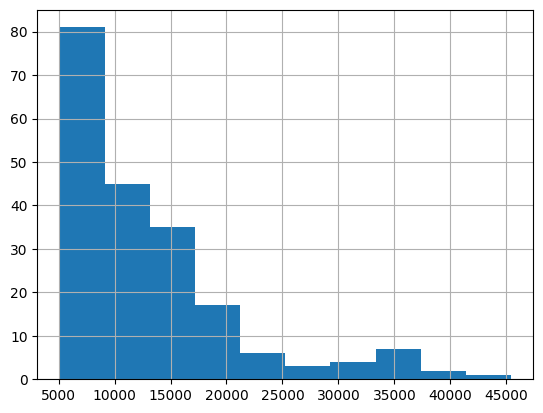

In [298]:
data["price"].hist()

<Axes: xlabel='price'>

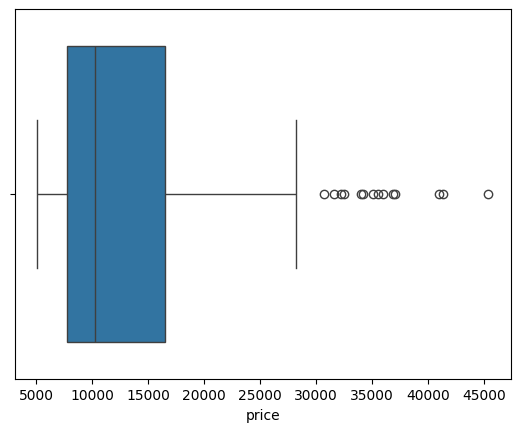

In [299]:
sns.boxplot(x = data["price"])

In [300]:
data["price"].nlargest(20)

74     45400
16     41315
73     40960
128    37028
17     36880
49     36000
48     35550
72     35056
71     34184
127    34028
126    32528
47     32250
70     31600
15     30760
68     28248
69     28176
67     25552
14     24565
8      23875
204    22625
Name: price, dtype: int64

<Axes: xlabel='price'>

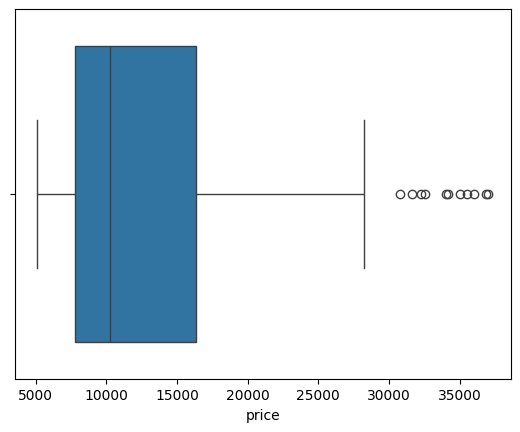

In [301]:
data = data[data["price"] < 40000]
sns.boxplot(x = data["price"])

<Axes: >

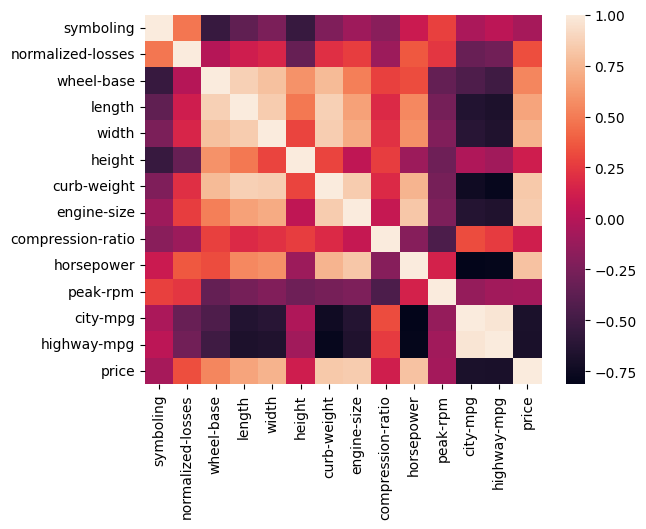

In [302]:
numeric_data = data.select_dtypes(include = ["number"])
corr = numeric_data.corr()
sns.heatmap(corr)

In [303]:
data = data.drop(["width", "curb-weight", "highway-mpg", "horsepower"], axis = 1)

In [304]:
data = pd.get_dummies(data, drop_first = True)
data

,symboling,normalized-losses,wheel-base,length,height,engine-size,compression-ratio,peak-rpm,city-mpg,price,...,stroke_3.47,stroke_3.5,stroke_3.52,stroke_3.54,stroke_3.58,stroke_3.64,stroke_3.86,stroke_3.9,stroke_4.17,stroke_?
0,3,125.912731,88.6,168.8,48.8,130,9.0,5000.0,21,13495,...,False,False,False,False,False,False,False,False,False,False
1,3,125.912731,88.6,168.8,48.8,130,9.0,5000.0,21,16500,...,False,False,False,False,False,False,False,False,False,False
2,1,125.912731,94.5,171.2,52.4,152,9.0,5000.0,19,16500,...,True,False,False,False,False,False,False,False,False,False
3,2,164.000000,99.8,176.6,54.3,109,10.0,5500.0,24,13950,...,False,False,False,False,False,False,False,False,False,False
4,2,164.000000,99.4,176.6,54.3,136,8.0,5500.0,18,17450,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,-1,95.000000,109.1,188.8,55.5,141,9.5,5400.0,23,16845,...,False,False,False,False,False,False,False,False,False,False
201,-1,95.000000,109.1,188.8,55.5,141,8.7,5300.0,19,19045,...,False,False,False,False,False,False,False,False,False,False
202,-1,95.000000,109.1,188.8,55.5,173,8.8,5500.0,18,21485,...,False,False,False,False,False,False,False,False,False,False
203,-1,95.000000,109.1,188.8,55.5,145,23.0,4800.0,26,22470,...,False,False,False,False,False,False,False,False,False,False


In [305]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

X = data.drop(['price'], axis = 1)
y = data["price"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [306]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

In [307]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

In [308]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred_rf)
mse = mean_squared_error(y_test, y_pred_rf)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_rf)
r2 ** 2
r22 = r2_score(y_test, y_pred_lr)
r22 ** 2, r2 ** 2

(0.7806594543056835, 0.9016255652358905)

In [205]:
importances = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print(importances.head(15))

               feature  importance
8             city-mpg    0.332539
5          engine-size    0.194931
2           wheel-base    0.189315
3               length    0.069061
7             peak-rpm    0.039993
6    compression-ratio    0.026307
1    normalized-losses    0.022513
80           bore_3.58    0.016935
38    drive-wheels_rwd    0.012218
52    fuel-system_mpfi    0.010638
16  make_mercedes-benz    0.010000
4               height    0.007578
0            symboling    0.006250
30    aspiration_turbo    0.005756
64           bore_3.13    0.005197


In [206]:
print("Первые 10 реальных цен:")
print(y_test.values[:10])
print("\nПервые 10 предсказанных:")
print(y_pred_lr[:10])
print()
print(y_pred_rf[:10])

Первые 10 реальных цен:
[22470  6849 11245  8778 15998  6295  5499 17669  7603 12290]

Первые 10 предсказанных:
[22345.3135445   7586.50162552  9899.58001974  7379.36183499
 16948.38484498  4945.75983176  7073.29864995 13607.90023427
  6723.20016341  9299.11757986]

[17145.45166667  7367.47833333 10087.96        8069.84333333
 17232.25        5557.49        7053.875      10054.44833333
  7682.04       13416.17333333]
